In [5]:
# house_price_model.ipynb
import pandas as pd

# Load the dataset
df = pd.read_csv('../data/housing.csv')

# Display the first few rows to understand its structure
df.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


# Step 3: Check for Missing Data

In [10]:
# Fill missing values for numeric columns with mean
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].mean())

# Fill missing values for categorical columns with mode
categorical_columns = df.select_dtypes(include=['object']).columns
df[categorical_columns] = df[categorical_columns].fillna(df[categorical_columns].mode().iloc[0])

# Check if there are any missing values left
print(df.isnull().sum())


price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


# Step 4: Feature Selection

In [21]:
import os
print(os.getcwd())


C:\Users\yashp\House_Price_Prediction\Notebooks


In [25]:
df = pd.read_csv(r'..\Data\Housing.csv')


In [31]:
# Split the dataset into features (X) and target (y)
X = df.drop(columns=['price'])  # Use 'price' as the target column
y = df['price']  # Set the target variable to 'price'

# Split data into training and testing sets (80% train, 20% test)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [33]:
from sklearn.preprocessing import StandardScaler

# Scale the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [35]:
from sklearn.linear_model import LinearRegression

# Initialize the model
model = LinearRegression()

# Train the model on the training data
model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = model.predict(X_test_scaled)

# Evaluate the model
from sklearn.metrics import mean_squared_error, r2_score

# Calculate the Mean Squared Error (MSE) and R-squared (R2) score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")


Mean Squared Error: 1754318687330.669
R-squared: 0.6529242642153175


In [37]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model on the training data
rf_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluate the model
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Mean Squared Error: {mse_rf}")
print(f"Random Forest R-squared: {r2_rf}")


Random Forest Mean Squared Error: 1959323004717.2698
Random Forest R-squared: 0.6123660550314123


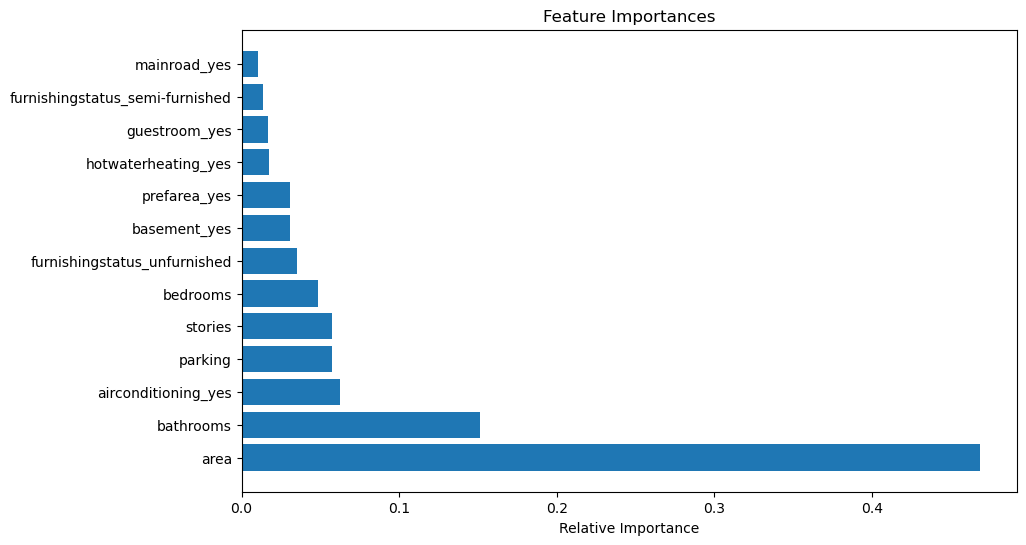

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# Get feature importances
importances = rf_model.feature_importances_

# Sort the features by importance
indices = np.argsort(importances)[::-1]

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.barh(range(X_train_scaled.shape[1]), importances[indices], align="center")
plt.yticks(range(X_train_scaled.shape[1]), np.array(X.columns)[indices])
plt.xlabel("Relative Importance")
plt.show()


In [41]:
from sklearn.model_selection import cross_val_score

# Cross-validation for Random Forest
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='neg_mean_squared_error')

# Display average cross-validation score
print(f"Cross-validation Mean Squared Error: {-cv_scores.mean()}")


Cross-validation Mean Squared Error: 2810782717179.328


In [45]:
# Linear Regression Model
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Random Forest Model
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [47]:
# Predict using Linear Regression
y_pred_lr = lr_model.predict(X_test)

# Predict using Random Forest
y_pred_rf = rf_model.predict(X_test)


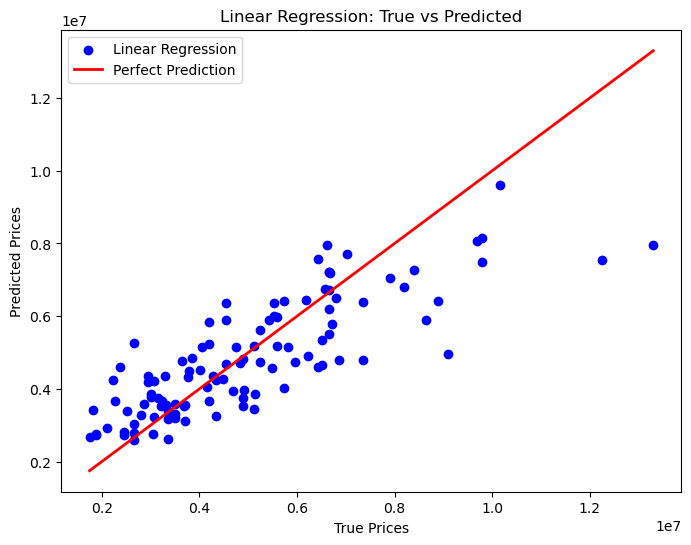

In [49]:
import matplotlib.pyplot as plt

# Plot true vs predicted values for Linear Regression
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lr, color='blue', label="Linear Regression")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, label='Perfect Prediction')
plt.title("Linear Regression: True vs Predicted")
plt.xlabel("True Prices")
plt.ylabel("Predicted Prices")
plt.legend()
plt.show()


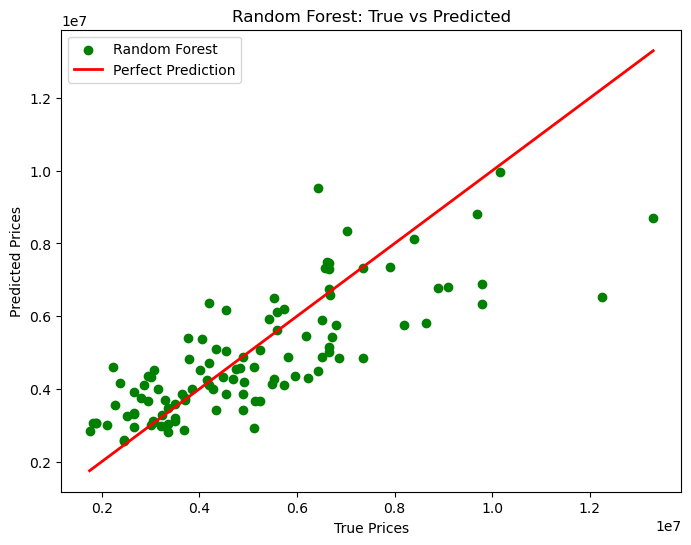

In [51]:
# Plot true vs predicted values for Random Forest
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, color='green', label="Random Forest")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, label='Perfect Prediction')
plt.title("Random Forest: True vs Predicted")
plt.xlabel("True Prices")
plt.ylabel("Predicted Prices")
plt.legend()
plt.show()


In [53]:
from sklearn.metrics import mean_squared_error, r2_score

# Evaluate Linear Regression
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

# Evaluate Random Forest
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Linear Regression MSE: {mse_lr}")
print(f"Linear Regression R²: {r2_lr}")

print(f"Random Forest MSE: {mse_rf}")
print(f"Random Forest R²: {r2_rf}")


Linear Regression MSE: 1754318687330.6643
Linear Regression R²: 0.6529242642153184
Random Forest MSE: 1961585044320.3433
Random Forest R²: 0.611918531405699


In [55]:
print(f"y_test shape: {y_test.shape}")
print(f"y_pred_lr shape: {y_pred_lr.shape}")


y_test shape: (109,)
y_pred_lr shape: (109,)


In [57]:
# Compare MSE and R² scores
print("Model Comparison:")
print(f"Linear Regression MSE: {mse_lr}, R²: {r2_lr}")
print(f"Random Forest MSE: {mse_rf}, R²: {r2_rf}")


Model Comparison:
Linear Regression MSE: 1754318687330.6643, R²: 0.6529242642153184
Random Forest MSE: 1961585044320.3433, R²: 0.611918531405699


In [59]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter grid for RandomForest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

# GridSearchCV to find the best parameters
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

# Best parameters found by GridSearchCV
print("Best parameters for Random Forest:")
print(grid_search.best_params_)

# Using the best model to make predictions
best_rf_model = grid_search.best_estimator_
y_pred_rf_optimized = best_rf_model.predict(X_test)

# Evaluate optimized Random Forest
mse_rf_optimized = mean_squared_error(y_test, y_pred_rf_optimized)
r2_rf_optimized = r2_score(y_test, y_pred_rf_optimized)

print(f"Optimized Random Forest MSE: {mse_rf_optimized}")
print(f"Optimized Random Forest R²: {r2_rf_optimized}")


Best parameters for Random Forest:
{'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 50}
Optimized Random Forest MSE: 2051535568409.7737
Optimized Random Forest R²: 0.5941226516958042


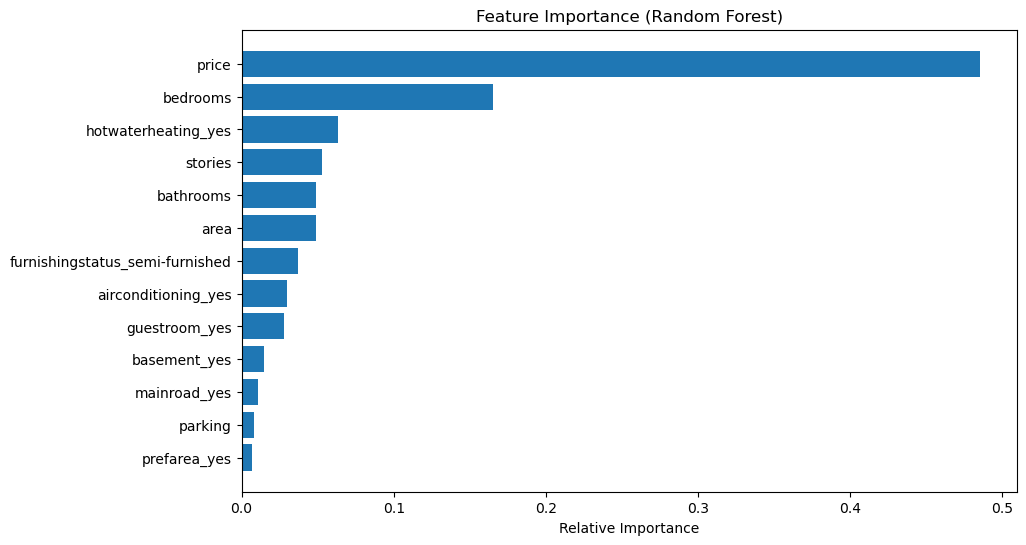

In [61]:
# Feature importance from Random Forest
importances = best_rf_model.feature_importances_
indices = importances.argsort()

# Plotting feature importance
plt.figure(figsize=(10, 6))
plt.title("Feature Importance (Random Forest)")
plt.barh(range(len(importances)), importances[indices], align='center')
plt.yticks(range(len(importances)), df.columns[indices])
plt.xlabel("Relative Importance")
plt.show()


In [63]:
import joblib

# Save the best model (Random Forest)
joblib.dump(best_rf_model, 'best_rf_model.pkl')

# Load the saved model (for later use)
loaded_model = joblib.load('best_rf_model.pkl')


In [69]:
# Get the columns from the training data (X_train)
train_columns = X_train.columns

# Reorder the columns in the new data to match the order of X_train
new_data = new_data[train_columns]

# Make predictions using the trained model
new_pred = loaded_model.predict(new_data)
print(f"Predicted price for new data: {new_pred[0]}")


Predicted price for new data: 5524637.492463093


In [71]:
import joblib

# Save the trained model
joblib.dump(loaded_model, 'house_price_model.pkl')
print("Model saved successfully.")


Model saved successfully.


In [73]:
# Load the trained model from the file
loaded_model = joblib.load('house_price_model.pkl')

# Predict using the loaded model
new_pred = loaded_model.predict(new_data)
print(f"Predicted price for new data: {new_pred[0]}")


Predicted price for new data: 5524637.492463093


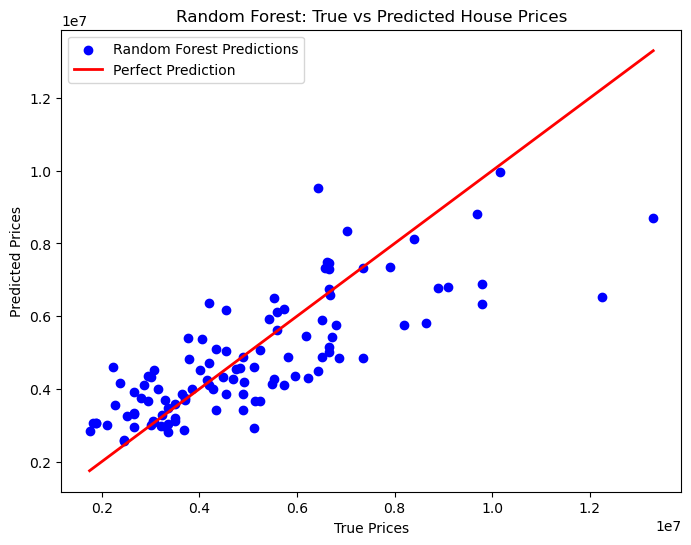

In [75]:
# If you have true values (y_test), you can plot them against the predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, color='blue', label="Random Forest Predictions")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, label="Perfect Prediction")
plt.xlabel("True Prices")
plt.ylabel("Predicted Prices")
plt.title("Random Forest: True vs Predicted House Prices")
plt.legend()
plt.show()


In [77]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred_rf)
print(f"R2 Score: {r2}")


R2 Score: 0.611918531405699


In [79]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred_rf)
print(f"Mean Absolute Error (MAE): {mae}")


Mean Absolute Error (MAE): 1021546.0353211008


In [81]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred_rf)
print(f"Mean Squared Error (MSE): {mse}")


Mean Squared Error (MSE): 1961585044320.3433


In [83]:
import numpy as np

rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse}")


Root Mean Squared Error (RMSE): 1400565.9728553821


In [85]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize Random Forest model
rf = RandomForestRegressor()

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

# Fit GridSearchCV
grid_search.fit(X_train, y_train)

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print(f"Best Parameters: {best_params}")
print(f"Best Score: {best_score}")


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 300}
Best Score: 0.6199045860084869


In [86]:
from sklearn.model_selection import cross_val_score

# Cross-validation with Random Forest
cv_scores = cross_val_score(loaded_model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')

print(f"Cross-validation scores: {cv_scores}")
print(f"Mean cross-validation score: {cv_scores.mean()}")


Cross-validation scores: [-1.45735081e+12 -1.00563725e+12 -6.21309401e+11 -1.54952197e+12
 -1.38385193e+12]
Mean cross-validation score: -1203534272398.031


In [87]:
mape = np.mean(np.abs((y_test - y_pred_rf) / y_test)) * 100
print(f"Mean Absolute Percentage Error (MAPE): {mape}")


Mean Absolute Percentage Error (MAPE): 21.80365198635862


In [88]:
def adjusted_r2_score(y_true, y_pred, X):
    n = len(y_true)
    p = X.shape[1]  # number of features
    r2 = r2_score(y_true, y_pred)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    return adj_r2

adj_r2 = adjusted_r2_score(y_test, y_pred_rf, X_test)
print(f"Adjusted R2 Score: {adj_r2}")


Adjusted R2 Score: 0.5588126462296368


In [93]:
pip install flask pandas scikit-learn joblib


Note: you may need to restart the kernel to use updated packages.


In [95]:
import joblib
joblib.dump(model, 'model.pkl')


['model.pkl']